# Desafio 11 — Reconhecimento de Atividade Humana

**Disciplina:** Machine Learning — Teoria e Aplicado  
**Grupo:** 11  
**Dataset:** UCI HAR (Human Activity Recognition with Smartphones)  
**Objetivo:** Classificar 6 atividades humanas a partir de 561 features extraídas de acelerômetro e giroscópio.

---
## Imports e Configuração

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.multiclass import OneVsRestClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)

print('Ambiente pronto!')

Ambiente pronto!


### Carregamento dos Dados

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

df = pd.concat([df_train, df_test], ignore_index=True)

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}  |  Total: {df.shape}')
print(f'Features: {df.shape[1] - 2} (excluindo subject e Activity)')
print(f'Classes: {df["Activity"].nunique()}')
print(f'NaN: {df.isnull().sum().sum()}')
df.head()

Train: (2560, 563)  |  Test: (2719, 563)  |  Total: (5279, 563)
Features: 561 (excluindo subject e Activity)
Classes: 6
NaN: 820


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1.0,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1.0,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1.0,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1.0,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1.0,STANDING


---
## Etapa 1 — Análise Exploratória (EDA)

### 1.1 Distribuição das 6 Classes de Atividade

Contagem por classe:
Activity
WALKING               955
STANDING              953
LAYING                936
SITTING               856
WALKING_UPSTAIRS      822
WALKING_DOWNSTAIRS    755
Name: count, dtype: int64

Proporção min/max: 0.79


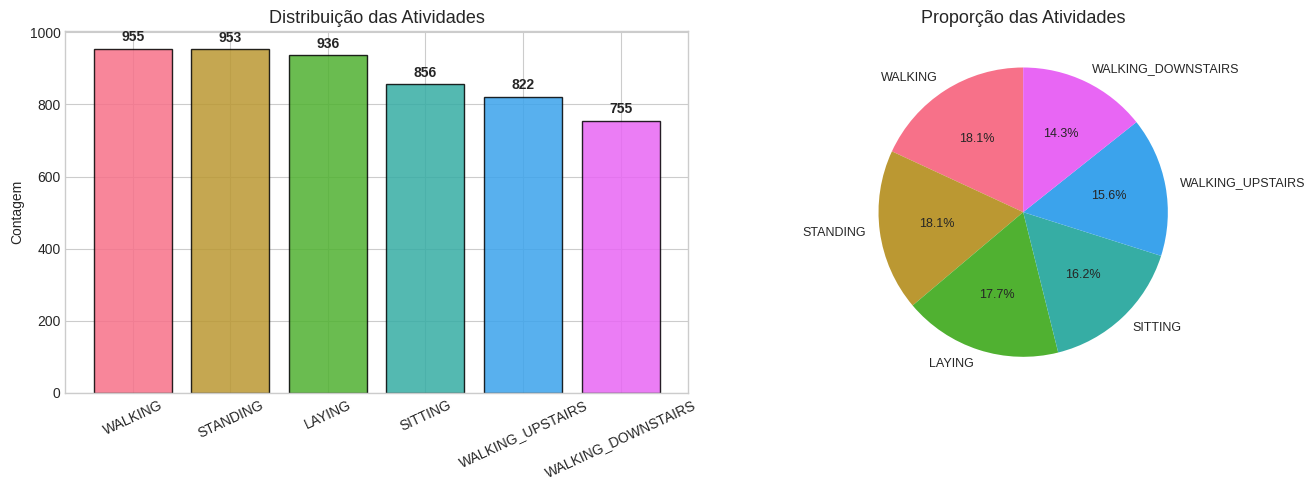

In [3]:
activity_counts = df['Activity'].value_counts()
print('Contagem por classe:')
print(activity_counts)
print(f'\nProporção min/max: {activity_counts.min() / activity_counts.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = sns.color_palette('husl', n_colors=6)
axes[0].bar(activity_counts.index, activity_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribuição das Atividades', fontsize=13)
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(activity_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=10)

# Gráfico de pizza
axes[1].pie(activity_counts.values, labels=activity_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Proporção das Atividades', fontsize=13)

plt.tight_layout()
plt.show()

### 1.2 Boxplots de Features por Atividade

Seleção de features representativas: médias e desvios do acelerômetro corporal e giroscópio.

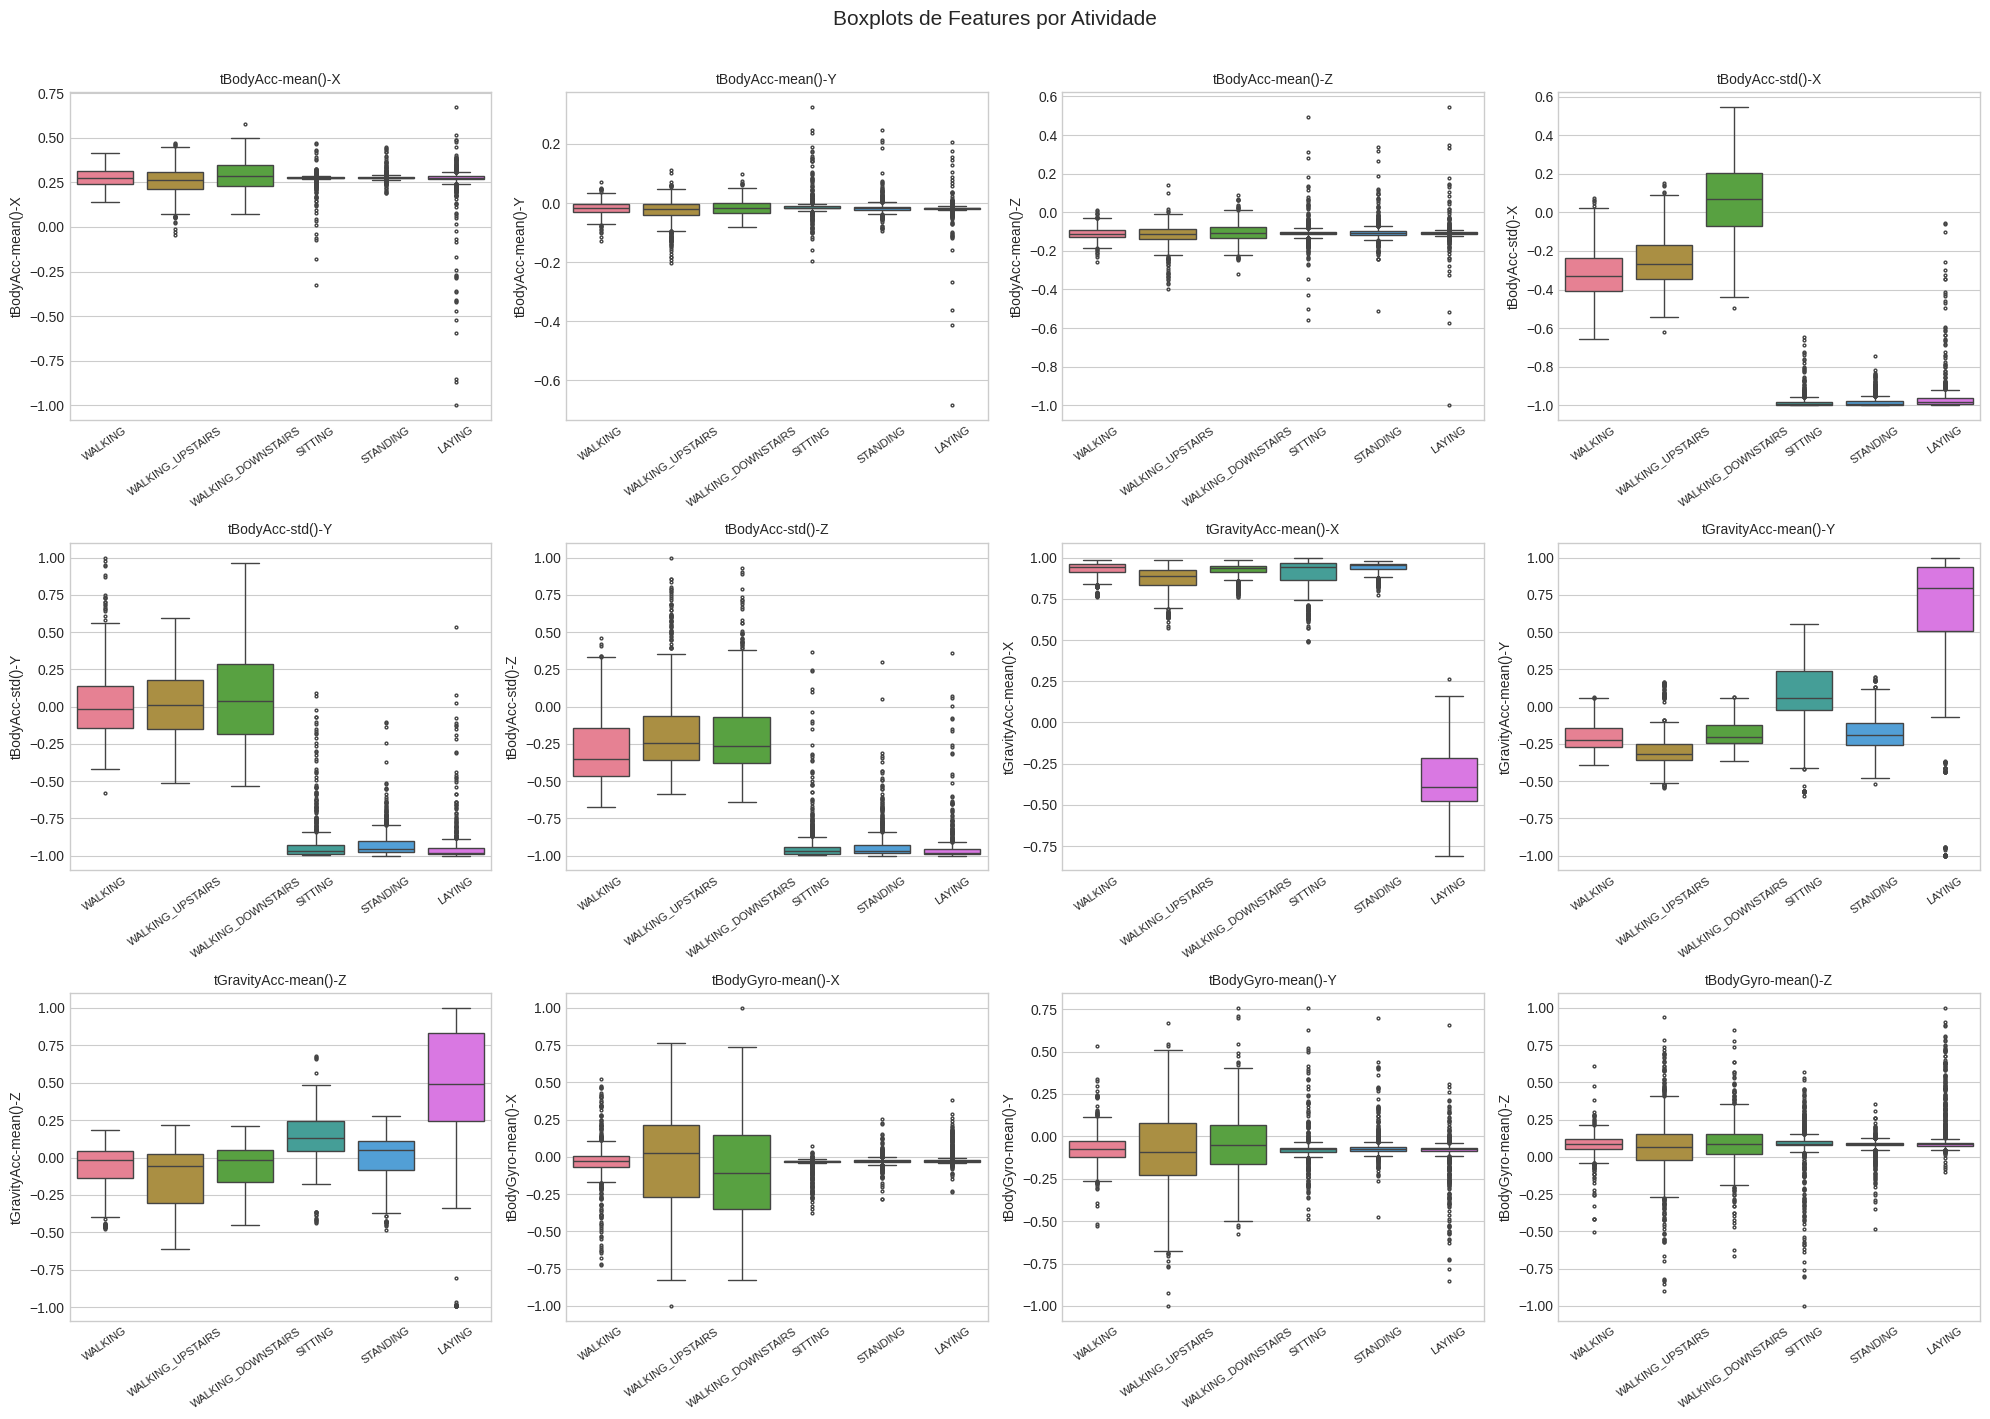

In [4]:
features_eda = [
    'tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
    'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
    'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',
    'tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

activity_order = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                  'SITTING', 'STANDING', 'LAYING']

for i, feat in enumerate(features_eda):
    sns.boxplot(data=df, x='Activity', y=feat, order=activity_order,
                ax=axes[i], palette='husl', fliersize=2)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35, labelsize=8)

plt.suptitle('Boxplots de Features por Atividade', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Análise de Similaridade entre Atividades

Cálculo das médias das features por classe para identificar quais atividades são mais semelhantes (e potencialmente mais confundidas).

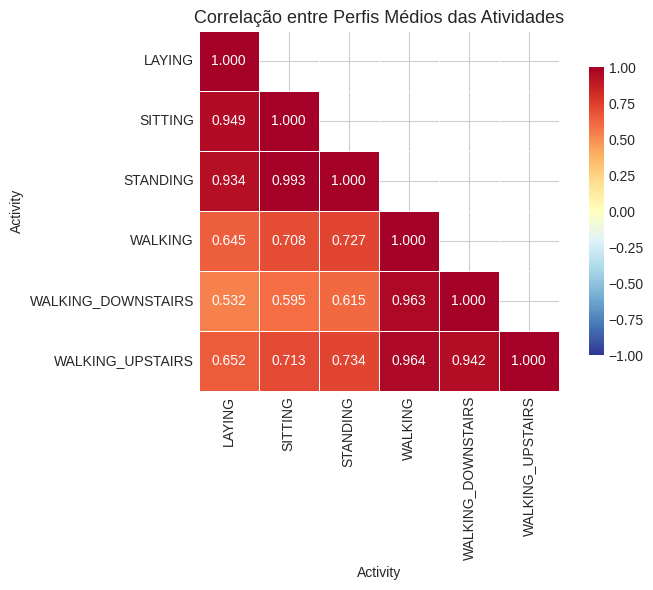

Pares de atividades mais similares (maior correlação):
  SITTING ↔ STANDING: 0.9927
  WALKING ↔ WALKING_UPSTAIRS: 0.9640
  WALKING ↔ WALKING_DOWNSTAIRS: 0.9630
  LAYING ↔ SITTING: 0.9488
  WALKING_DOWNSTAIRS ↔ WALKING_UPSTAIRS: 0.9422


In [5]:
feature_cols = [c for c in df.columns if c not in ['subject', 'Activity']]

# Média das features por atividade
class_means = df.groupby('Activity')[feature_cols].mean()

# Correlação entre os perfis médios das classes
class_corr = class_means.T.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(class_corr, dtype=bool), k=1)
sns.heatmap(class_corr, annot=True, fmt='.3f', cmap='RdYlBu_r',
            vmin=-1, vmax=1, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlação entre Perfis Médios das Atividades', fontsize=13)
plt.tight_layout()
plt.show()

# Top pares mais correlacionados (mais confundíveis)
print('Pares de atividades mais similares (maior correlação):')
corr_pairs = []
for i in range(len(class_corr)):
    for j in range(i+1, len(class_corr)):
        corr_pairs.append((class_corr.index[i], class_corr.columns[j], class_corr.iloc[i, j]))
corr_pairs.sort(key=lambda x: x[2], reverse=True)
for a, b, c in corr_pairs[:5]:
    print(f'  {a} ↔ {b}: {c:.4f}')

### 1.4 Distribuição de Features-chave por Atividade (KDE)

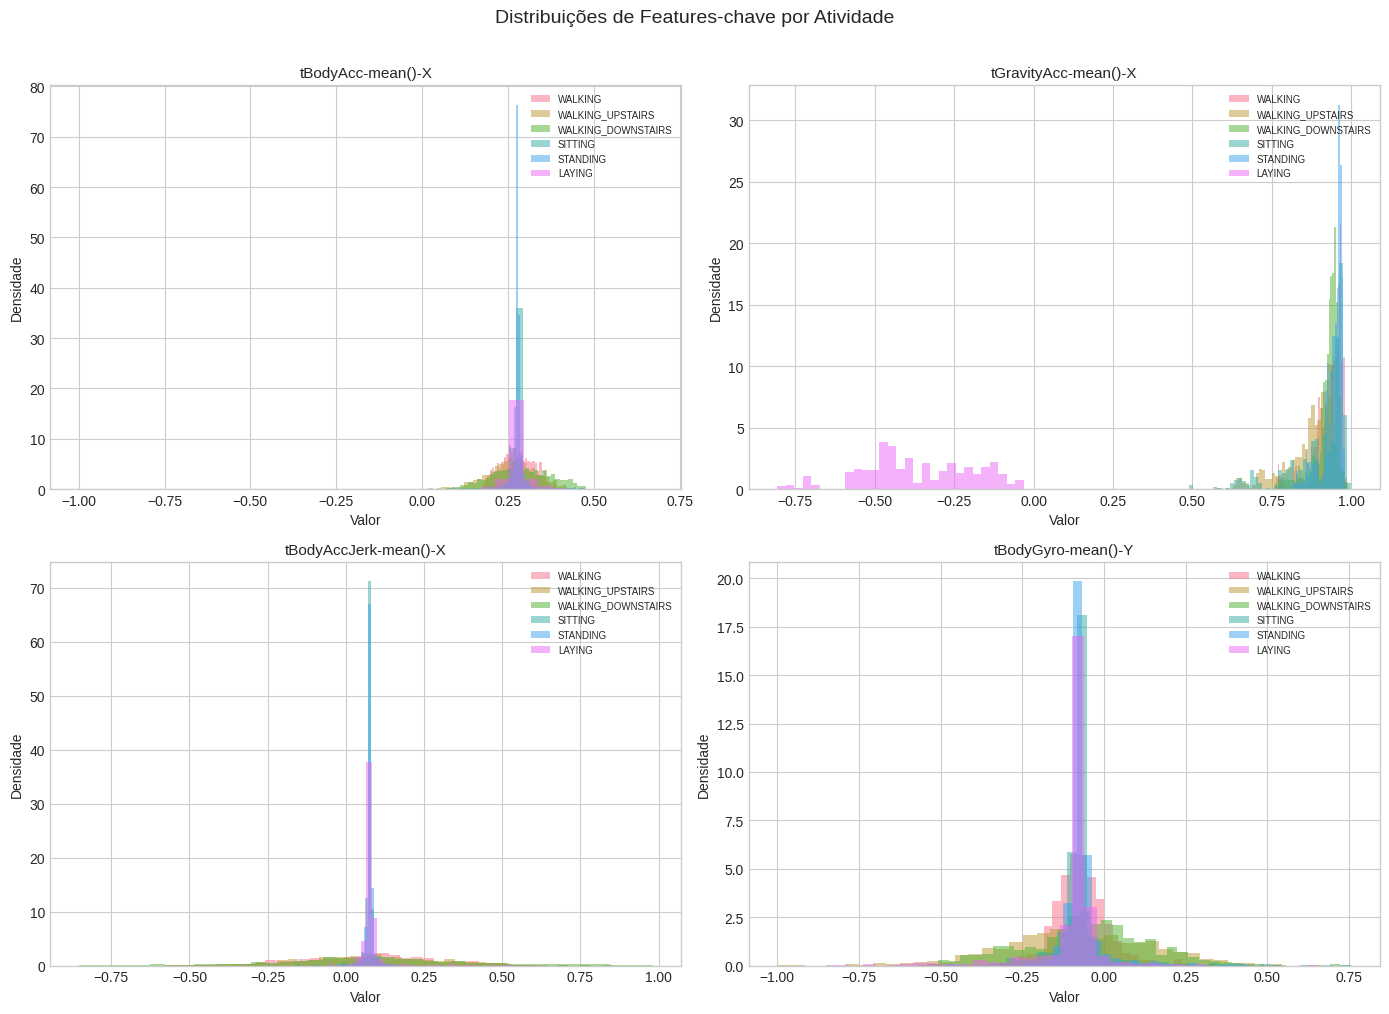

In [6]:
key_features = ['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X',
                'tBodyAccJerk-mean()-X', 'tBodyGyro-mean()-Y']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for act in activity_order:
        subset = df[df['Activity'] == act][feat]
        axes[i].hist(subset, bins=40, alpha=0.5, label=act, density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidade')
    axes[i].legend(fontsize=7, loc='upper right')

plt.suptitle('Distribuições de Features-chave por Atividade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observações da EDA:**
- Classes razoavelmente balanceadas (proporção min/max ≈ 0.72)
- Walking, Walking_Upstairs e Walking_Downstairs apresentam perfis de aceleração similares — maior potencial de confusão
- Sitting e Standing são muito correlacionados entre si, diferindo-se mais claramente de Laying
- `tGravityAcc-mean()-X` é altamente discriminativa entre atividades dinâmicas e estáticas

---
## Etapa 2 — Pré-processamento

### 2.1 Separação Features / Target

In [14]:
df_model = df.dropna(subset=['Activity']).copy()

feature_cols = [c for c in df_model.columns if c not in ['subject', 'Activity']]

X = df_model[feature_cols]
y = df_model['Activity']

print(f'Linhas usadas: {df_model.shape[0]}')
print(f'Features: {len(feature_cols)}')
print(f'NaN em Activity: {df_model["Activity"].isna().sum()}')
print(f'NaN nas features antes da imputação: {X.isna().sum().sum()}')

# Encoder para rótulos numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('\nMapeamento de classes:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

print(f'\nX: {X.shape}  |  y: {y_encoded.shape}')

Linhas usadas: 5277
Features: 561
NaN em Activity: 0
NaN nas features antes da imputação: 0

Mapeamento de classes:
  0 -> LAYING
  1 -> SITTING
  2 -> STANDING
  3 -> WALKING
  4 -> WALKING_DOWNSTAIRS
  5 -> WALKING_UPSTAIRS

X: (5277, 561)  |  y: (5277,)


### 2.2 Remoção de Features Constantes / Quase-constantes

In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

vt = VarianceThreshold(threshold=0.01)
X_filtered = vt.fit_transform(X_imputed)

kept_mask = vt.get_support()
kept_features = np.array(feature_cols)[kept_mask]
removed_features = np.array(feature_cols)[~kept_mask]

print(f'Features originais: {X.shape[1]}')
print(f'Features removidas (variância < 0.01): {len(removed_features)}')
print(f'Features mantidas: {X_filtered.shape[1]}')

if len(removed_features) > 0:
    print(f'\nExemplos removidas: {list(removed_features[:10])}')

Features originais: 561
Features removidas (variância < 0.01): 45
Features mantidas: 516

Exemplos removidas: [np.str_('tBodyAcc-mean()-X'), np.str_('tBodyAcc-mean()-Y'), np.str_('tBodyAcc-mean()-Z'), np.str_('tGravityAcc-std()-X'), np.str_('tGravityAcc-std()-Y'), np.str_('tGravityAcc-mad()-X'), np.str_('tGravityAcc-mad()-Y'), np.str_('tGravityAcc-iqr()-X'), np.str_('tGravityAcc-iqr()-Y'), np.str_('tGravityAcc-iqr()-Z')]


### 2.3 Normalização

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

print(f'Média após normalização: {X_scaled.mean():.6f}')
print(f'Std após normalização:   {X_scaled.std():.6f}')
print(f'NaN após normalização:   {np.isnan(X_scaled).sum()}')

Média após normalização: 0.000000
Std após normalização:   1.000000
NaN após normalização:   0


### 2.4 Divisão Treino / Validação / Teste (Estratificada)

In [17]:
# 60% treino, 20% validação, 20% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.4, stratify=y_encoded, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print('DIVISÃO TREINO/VALIDAÇÃO/TESTE:')
print(f'  TREINO:    {X_train.shape[0]} ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'  VALIDAÇÃO: {X_val.shape[0]} ({X_val.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'  TESTE:     {X_test.shape[0]} ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')

# Verificar estratificação
print('\nDistribuição (%) por split:')
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = pd.Series(y_split).value_counts(normalize=True).sort_index()
    print(f'  {name}: {[f"{v:.2f}" for v in dist.values]}')

DIVISÃO TREINO/VALIDAÇÃO/TESTE:
  TREINO:    3166 (60%)
  VALIDAÇÃO: 1055 (20%)
  TESTE:     1056 (20%)

Distribuição (%) por split:
  Train: ['0.18', '0.16', '0.18', '0.18', '0.14', '0.16']
  Val: ['0.18', '0.16', '0.18', '0.18', '0.14', '0.16']
  Test: ['0.18', '0.16', '0.18', '0.18', '0.14', '0.16']


---
## Etapa 3 — Comparação de Modelos

Classificadores: **KNN**, **SVC (RBF)**, **Random Forest**  
Avaliação: **Stratified K-Fold (k=5)** + métricas macro

### 3.1 Definição dos Modelos e Cross-Validation

In [18]:
models = {
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVC (RBF)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    print(f'Treinando {name}...')
    t0 = time.time()
    cv = cross_validate(model, X_train, y_train, cv=skf,
                        scoring=scoring, return_train_score=False, n_jobs=-1)
    elapsed = time.time() - t0
    cv_results[name] = {
        'accuracy': cv['test_accuracy'].mean(),
        'accuracy_std': cv['test_accuracy'].std(),
        'precision_macro': cv['test_precision_macro'].mean(),
        'recall_macro': cv['test_recall_macro'].mean(),
        'f1_macro': cv['test_f1_macro'].mean(),
        'cv_time': elapsed
    }
    print(f'  Acc: {cv_results[name]["accuracy"]:.4f} ± {cv_results[name]["accuracy_std"]:.4f}  '
          f'| F1: {cv_results[name]["f1_macro"]:.4f}  | Tempo: {elapsed:.2f}s')

print('\nCross-validation concluída!')

Treinando KNN (k=7)...
  Acc: 0.9501 ± 0.0095  | F1: 0.9508  | Tempo: 5.04s
Treinando SVC (RBF)...
  Acc: 0.9833 ± 0.0048  | F1: 0.9835  | Tempo: 4.02s
Treinando Random Forest...
  Acc: 0.9694 ± 0.0052  | F1: 0.9692  | Tempo: 44.42s

Cross-validation concluída!


### 3.2 Tabela Comparativa (Cross-Validation)

In [19]:
df_cv = pd.DataFrame(cv_results).T
df_cv = df_cv[['accuracy', 'accuracy_std', 'precision_macro', 'recall_macro', 'f1_macro', 'cv_time']]
df_cv.columns = ['Acurácia', 'Acurácia (std)', 'Precisão Macro', 'Recall Macro', 'F1-Score Macro', 'Tempo CV (s)']
df_cv = df_cv.round(4)
print('=== RESULTADOS CROSS-VALIDATION (k=5) ===')
df_cv

=== RESULTADOS CROSS-VALIDATION (k=5) ===


,Acurácia,Acurácia (std),Precisão Macro,Recall Macro,F1-Score Macro,Tempo CV (s)
KNN (k=7),0.9501,0.0095,0.9515,0.9505,0.9508,5.0446
SVC (RBF),0.9833,0.0048,0.9835,0.9837,0.9835,4.0205
Random Forest,0.9694,0.0052,0.9693,0.9693,0.9692,44.4187


3.3 Tuning Amplo de Hiperparametros

In [24]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Tuning reduzido para rodar mais rápido
param_grids = {
    'KNN Tunado': {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'SVC-RBF Tunado': {
        'C': [1, 10],
        'gamma': ['scale', 0.01],
        'class_weight': [None]
    },
    'Random Forest Tunado': {
        'n_estimators': [100, 200],
        'max_depth': [None, 20],
        'max_features': ['sqrt'],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'bootstrap': [True]
    }
}

# Cross-validation menor para acelerar
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

searches = {
    'KNN Tunado': GridSearchCV(
        estimator=KNeighborsClassifier(n_jobs=-1),
        param_grid=param_grids['KNN Tunado'],
        scoring='f1_macro',
        cv=skf_fast,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    ),

    'SVC-RBF Tunado': GridSearchCV(
        estimator=SVC(kernel='rbf', random_state=42),
        param_grid=param_grids['SVC-RBF Tunado'],
        scoring='f1_macro',
        cv=skf_fast,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    ),

    'Random Forest Tunado': RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions=param_grids['Random Forest Tunado'],
        n_iter=10,
        scoring='f1_macro',
        cv=skf_fast,
        n_jobs=-1,
        refit=True,
        random_state=42,
        return_train_score=True,
        verbose=1
    )
}

tuned_models = {}
tuning_results = {}

for name, search in searches.items():
    print(f'Tuning {name}...')
    t0 = time.time()

    search.fit(X_train, y_train)

    elapsed = time.time() - t0

    tuned_models[name] = search.best_estimator_
    tuning_results[name] = {
        'f1_macro_cv': search.best_score_,
        'f1_macro_cv_std': search.cv_results_['std_test_score'][search.best_index_],
        'n_candidatos': len(search.cv_results_['params']),
        'tempo_tuning_s': elapsed,
        'melhores_parametros': search.best_params_
    }

    print(f'  Melhor F1 macro CV: {search.best_score_:.4f}')
    print(f'  Candidatos avaliados: {len(search.cv_results_["params"])}')
    print(f'  Melhores parametros: {search.best_params_}')
    print(f'  Tempo: {elapsed:.2f}s\n')

df_tuning = pd.DataFrame(tuning_results).T

df_tuning_display = df_tuning.copy()
df_tuning_display['melhores_parametros'] = df_tuning_display['melhores_parametros'].astype(str)

df_tuning_display = df_tuning_display.rename(columns={
    'f1_macro_cv': 'Melhor F1 Macro CV',
    'f1_macro_cv_std': 'Std F1 Macro CV',
    'n_candidatos': 'Candidatos Avaliados',
    'tempo_tuning_s': 'Tempo Tuning (s)',
    'melhores_parametros': 'Melhores Hiperparametros'
})

print('=== RESULTADOS DO TUNING DE HIPERPARAMETROS ===')
df_tuning_display

Tuning KNN Tunado...
  Melhor F1 macro CV: 0.9653
  Candidatos avaliados: 16
  Melhores parametros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
  Tempo: 90.41s

Tuning SVC-RBF Tunado...
  Melhor F1 macro CV: 0.9798
  Candidatos avaliados: 4
  Melhores parametros: {'C': 10, 'class_weight': None, 'gamma': 'scale'}
  Tempo: 32.15s

Tuning Random Forest Tunado...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Melhor F1 macro CV: 0.9640
  Candidatos avaliados: 10
  Melhores parametros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
  Tempo: 180.98s

=== RESULTADOS DO TUNING DE HIPERPARAMETROS ===


,Melhor F1 Macro CV,Std F1 Macro CV,Candidatos Avaliados,Tempo Tuning (s),Melhores Hiperparametros
KNN Tunado,0.96534,0.004278,16,90.408416,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei..."
SVC-RBF Tunado,0.979819,0.005455,4,32.153632,"{'C': 10, 'class_weight': None, 'gamma': 'scale'}"
Random Forest Tunado,0.96399,0.004238,10,180.979652,"{'n_estimators': 200, 'min_samples_split': 2, ..."


3.4 Modelos Selecionados Apos Tuning

In [25]:
models = tuned_models

print('Modelos finais selecionados apos tuning:')
for name, model in models.items():
    print(f'  {name}: {model}')


Modelos finais selecionados apos tuning:
  KNN Tunado: KNeighborsClassifier(metric='manhattan', n_jobs=-1, n_neighbors=3)
  SVC-RBF Tunado: SVC(C=10, random_state=42)
  Random Forest Tunado: RandomForestClassifier(min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)


### 3.5 Treino Final e Avaliação no Conjunto de Teste

In [26]:
test_results = {}
trained_models = {}

for name, model in models.items():
    # Treinar no conjunto de treino completo
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predições no teste
    y_pred = model.predict(X_test)

    # Tempo de inferência
    t0 = time.time()
    for _ in range(5):
        model.predict(X_test)
    inference_time = (time.time() - t0) / 5

    test_results[name] = {
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'inference_time': inference_time
    }

# Tabela de resultados no teste
df_test_results = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m != 'y_pred'}
    for k, vals in test_results.items()
}).T
df_test_results.columns = ['Acurácia', 'Precisão Macro', 'Recall Macro', 'F1-Score Macro', 'Tempo Inferência (s)']
df_test_results = df_test_results.round(4)
print('=== RESULTADOS NO CONJUNTO DE TESTE ===')
df_test_results

=== RESULTADOS NO CONJUNTO DE TESTE ===


,Acurácia,Precisão Macro,Recall Macro,F1-Score Macro,Tempo Inferência (s)
KNN Tunado,0.9697,0.9707,0.9702,0.9704,2.6296
SVC-RBF Tunado,0.9801,0.9806,0.9801,0.9803,0.6143
Random Forest Tunado,0.9583,0.9568,0.9576,0.9571,0.0941


### 3.6 Classification Report por Modelo

In [27]:
for name, res in test_results.items():
    print(f'\n{"=" * 50}')
    print(f'{name}')
    print('=' * 50)
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))


KNN Tunado
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       188
           SITTING       0.92      0.91      0.91       171
          STANDING       0.91      0.93      0.92       191
           WALKING       0.99      1.00      1.00       191
WALKING_DOWNSTAIRS       1.00      0.99      1.00       151
  WALKING_UPSTAIRS       1.00      1.00      1.00       164

          accuracy                           0.97      1056
         macro avg       0.97      0.97      0.97      1056
      weighted avg       0.97      0.97      0.97      1056


SVC-RBF Tunado
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       188
           SITTING       0.95      0.94      0.94       171
          STANDING       0.94      0.96      0.95       191
           WALKING       1.00      1.00      1.00       191
WALKING_DOWNSTAIRS       1.00      0.99      0.99       151
  WALKIN

### 3.7 Matrizes de Confusão

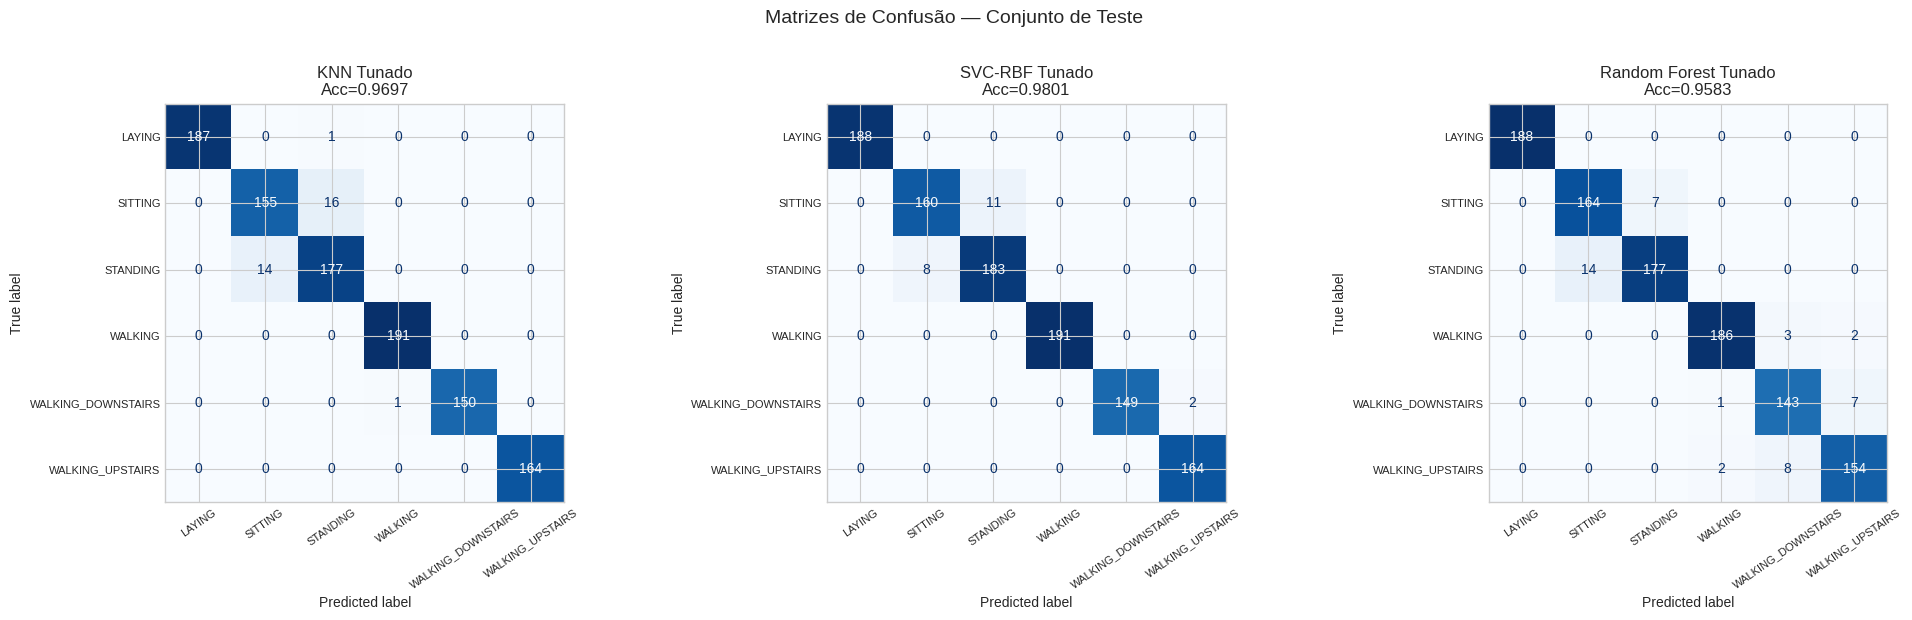

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{name}\nAcc={res["accuracy"]:.4f}', fontsize=12)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.8 Matrizes de Confusão Normalizadas

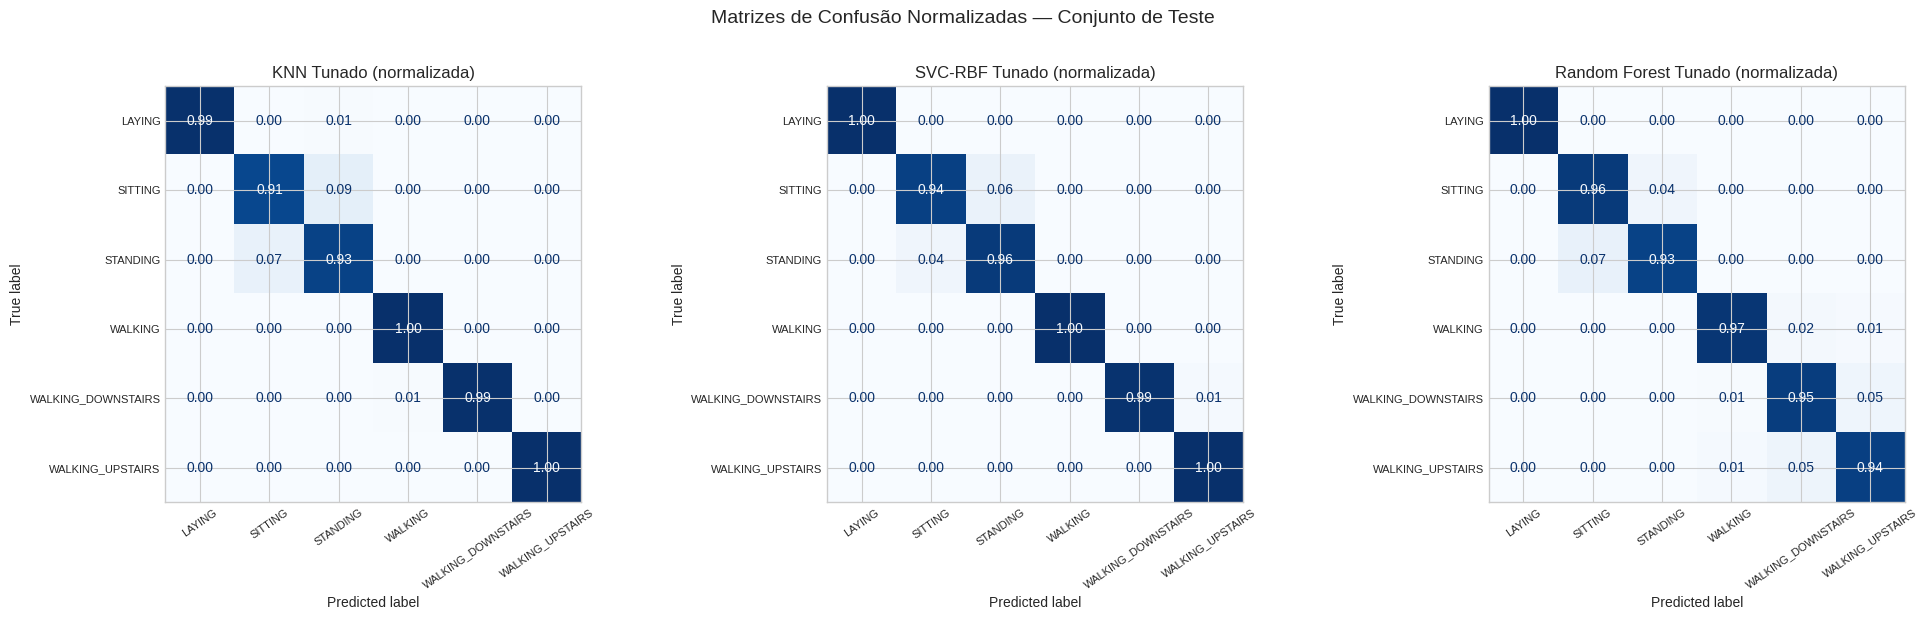

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
    ax.set_title(f'{name} (normalizada)', fontsize=12)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Matrizes de Confusão Normalizadas — Conjunto de Teste', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.9 Curvas ROC/AUC (One-vs-Rest)

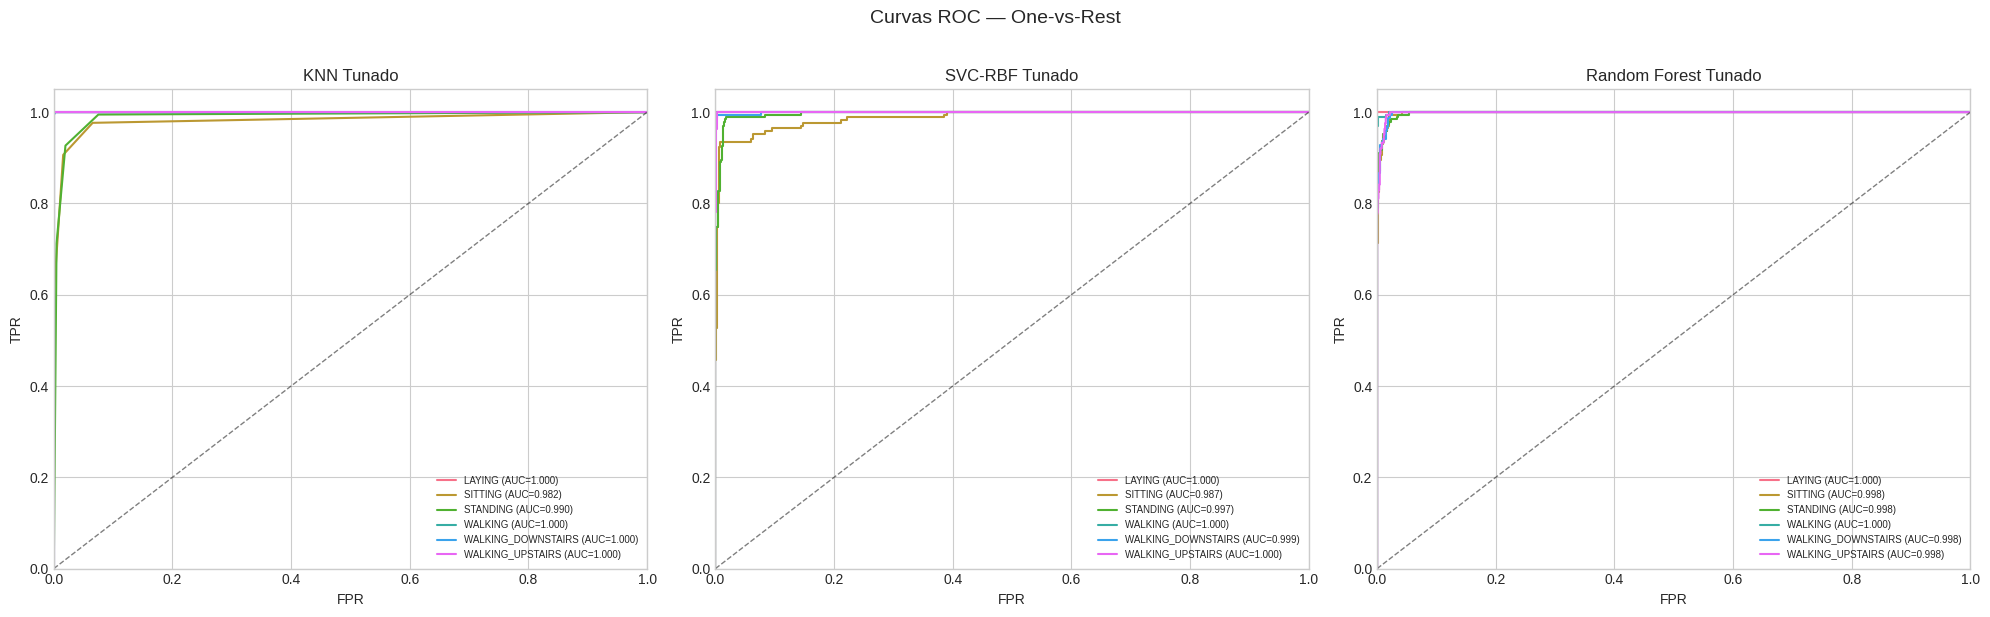

In [30]:
# Binarizar labels para ROC multiclasse
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    # Obter probabilidades ou decision_function
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    else:
        # SVC sem probability=True: usar decision_function
        y_score = model.decision_function(X_test)

    # ROC por classe
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.5, label=f'{le.classes_[i]} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'{name}', fontsize=12)
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Curvas ROC — One-vs-Rest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Etapa 4 — Análise Comparativa

### 4.1 Comparação Visual das Métricas

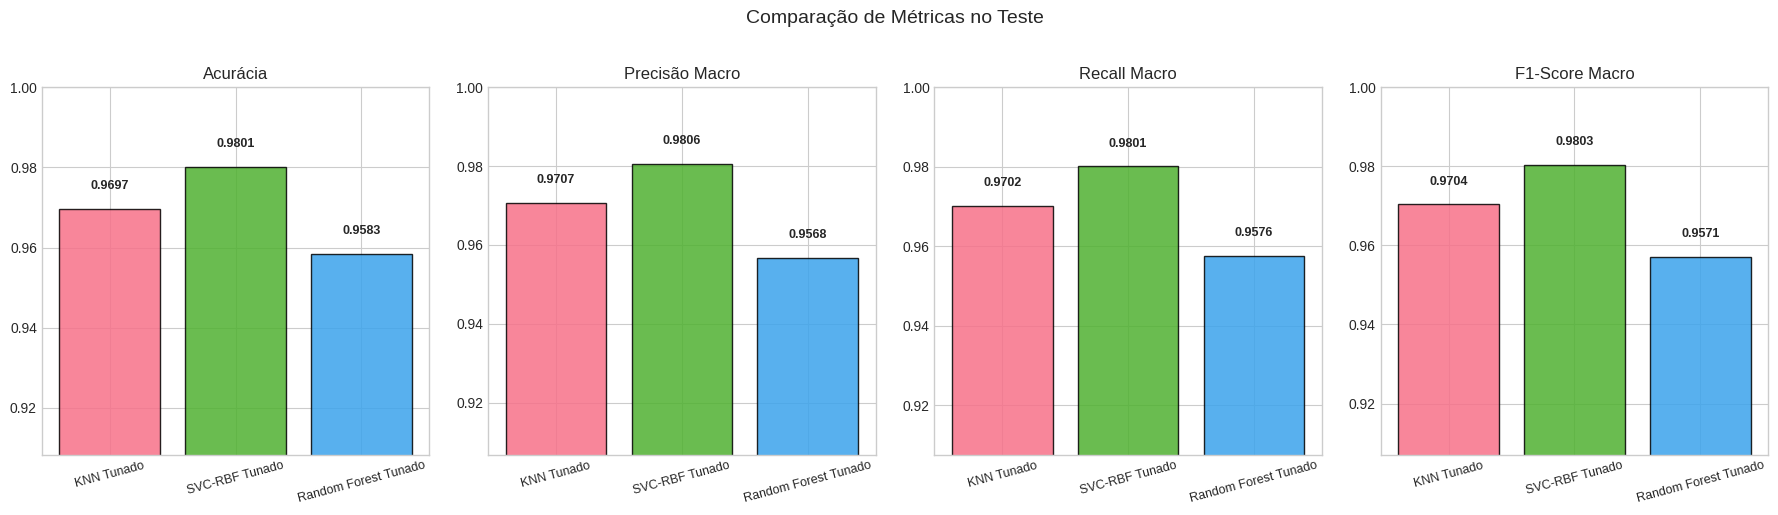

In [31]:
metrics_names = ['Acurácia', 'Precisão Macro', 'Recall Macro', 'F1-Score Macro']
model_names = list(test_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = sns.color_palette('husl', n_colors=3)

for i, metric in enumerate(metrics_names):
    col = metric.lower().replace('-', '_').replace(' ', '_')
    values = df_test_results[metric].values
    bars = axes[i].bar(model_names, values, color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_ylim(min(values) - 0.05, 1.0)
    axes[i].tick_params(axis='x', rotation=15, labelsize=9)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparação de Métricas no Teste', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Justificativa do Melhor Modelo

In [32]:
best_model_name = max(test_results, key=lambda k: test_results[k]['f1_macro'])
best_res = test_results[best_model_name]

print(f'MELHOR MODELO: {best_model_name}')
print(f'  Acurácia:       {best_res["accuracy"]:.4f}')
print(f'  Precisão Macro: {best_res["precision_macro"]:.4f}')
print(f'  Recall Macro:   {best_res["recall_macro"]:.4f}')
print(f'  F1-Score Macro: {best_res["f1_macro"]:.4f}')
print(f'  Tempo Infer.:   {best_res["inference_time"]:.4f}s')
print()
print('Justificativa:')
print(f'  O {best_model_name} obteve o melhor F1-Score Macro, métrica mais adequada')
print('  para classificação multiclasse por considerar precisão e recall simultaneamente.')
print('  Métricas macro garantem avaliação justa entre classes de tamanhos diferentes.')

MELHOR MODELO: SVC-RBF Tunado
  Acurácia:       0.9801
  Precisão Macro: 0.9806
  Recall Macro:   0.9801
  F1-Score Macro: 0.9803
  Tempo Infer.:   0.6143s

Justificativa:
  O SVC-RBF Tunado obteve o melhor F1-Score Macro, métrica mais adequada
  para classificação multiclasse por considerar precisão e recall simultaneamente.
  Métricas macro garantem avaliação justa entre classes de tamanhos diferentes.


### 4.3 Análise Detalhada da Matriz de Confusão

In [33]:
# Matriz de confusão do melhor modelo
best_pred = test_results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, best_pred)
cm_norm = confusion_matrix(y_test, best_pred, normalize='true')

# Identificar maiores confusões
print(f'Análise de confusão — {best_model_name}:')
print()

confusions = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i, j] > 0:
            confusions.append((le.classes_[i], le.classes_[j], cm[i, j], cm_norm[i, j]))

confusions.sort(key=lambda x: x[2], reverse=True)

print(f'{"Real":<22} {"Predito":<22} {"Count":>6} {"Taxa":>8}')
print('-' * 62)
for real, pred, count, rate in confusions[:10]:
    print(f'{real:<22} {pred:<22} {count:>6} {rate:>8.2%}')

print()
print('Principais confusões:')
print('  - Atividades de caminhada (Walking, Upstairs, Downstairs) são confundidas entre si')
print('    devido a padrões de aceleração similares.')
print('  - Sitting e Standing geram confusão mútua por serem atividades estáticas')
print('    com pouca variação nos sensores.')

Análise de confusão — SVC-RBF Tunado:

Real                   Predito                 Count     Taxa
--------------------------------------------------------------
SITTING                STANDING                   11    6.43%
STANDING               SITTING                     8    4.19%
WALKING_DOWNSTAIRS     WALKING_UPSTAIRS            2    1.32%

Principais confusões:
  - Atividades de caminhada (Walking, Upstairs, Downstairs) são confundidas entre si
    devido a padrões de aceleração similares.
  - Sitting e Standing geram confusão mútua por serem atividades estáticas
    com pouca variação nos sensores.


### 4.4 Feature Importance (Random Forest)

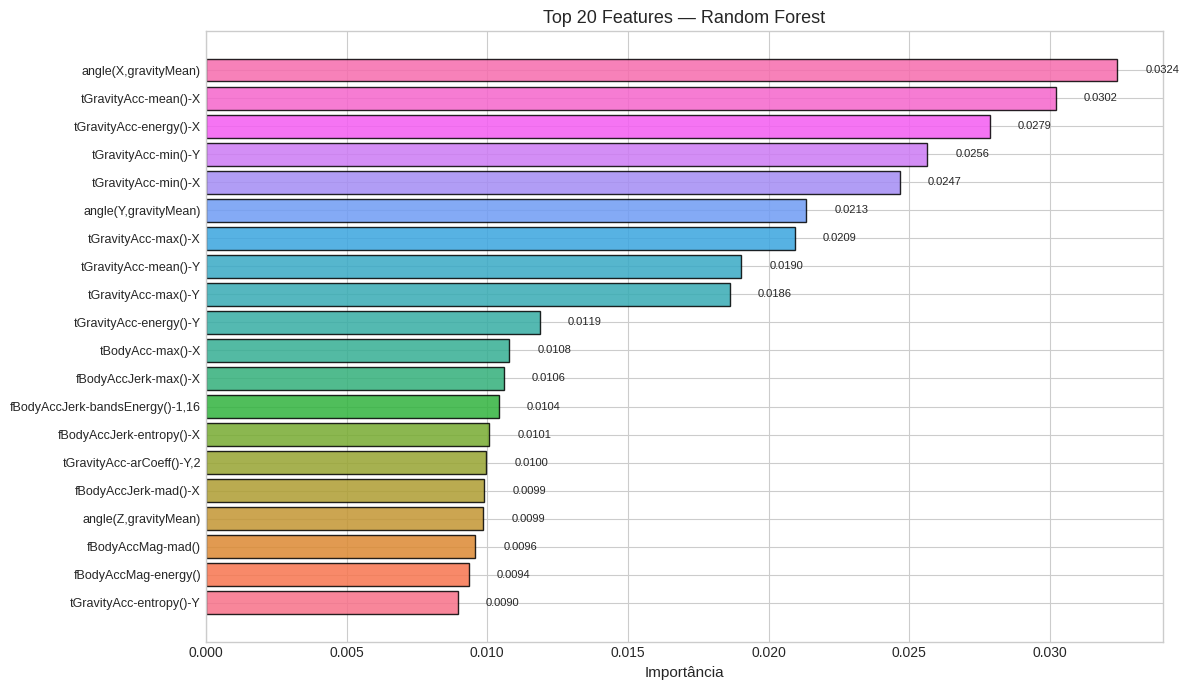


Top 20 features mais informativas:
   1. angle(X,gravityMean)                     0.0324
   2. tGravityAcc-mean()-X                     0.0302
   3. tGravityAcc-energy()-X                   0.0279
   4. tGravityAcc-min()-Y                      0.0256
   5. tGravityAcc-min()-X                      0.0247
   6. angle(Y,gravityMean)                     0.0213
   7. tGravityAcc-max()-X                      0.0209
   8. tGravityAcc-mean()-Y                     0.0190
   9. tGravityAcc-max()-Y                      0.0186
  10. tGravityAcc-energy()-Y                   0.0119
  11. tBodyAcc-max()-X                         0.0108
  12. fBodyAccJerk-max()-X                     0.0106
  13. fBodyAccJerk-bandsEnergy()-1,16          0.0104
  14. fBodyAccJerk-entropy()-X                 0.0101
  15. tGravityAcc-arCoeff()-Y,2                0.0100
  16. fBodyAccJerk-mad()-X                     0.0099
  17. angle(Z,gravityMean)                     0.0099
  18. fBodyAccMag-mad()                       

In [35]:
rf_model = trained_models['Random Forest Tunado']
importances = rf_model.feature_importances_

# Top 20 features
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]
top_features = kept_features[top_idx]
top_importances = importances[top_idx]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(top_n), top_importances[::-1], color=sns.color_palette('husl', top_n),
               edgecolor='black', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features[::-1], fontsize=9)
ax.set_xlabel('Importância', fontsize=11)
ax.set_title(f'Top {top_n} Features — Random Forest', fontsize=13)

for i, v in enumerate(top_importances[::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Tabela
print(f'\nTop {top_n} features mais informativas:')
for i, (feat, imp) in enumerate(zip(top_features, top_importances), 1):
    print(f'  {i:>2}. {feat:<40} {imp:.4f}')

### 4.5 Análise por Tipo de Sensor

Importância por tipo de sensor:
                        Importância Total  Qtd Features  Importância Média
Acelerômetro (Body)                0.4609         273.0             0.0017
Acelerômetro (Gravity)             0.3359          46.0             0.0073
Giroscópio                         0.1396         194.0             0.0007
Ângulo                             0.0636           3.0             0.0212


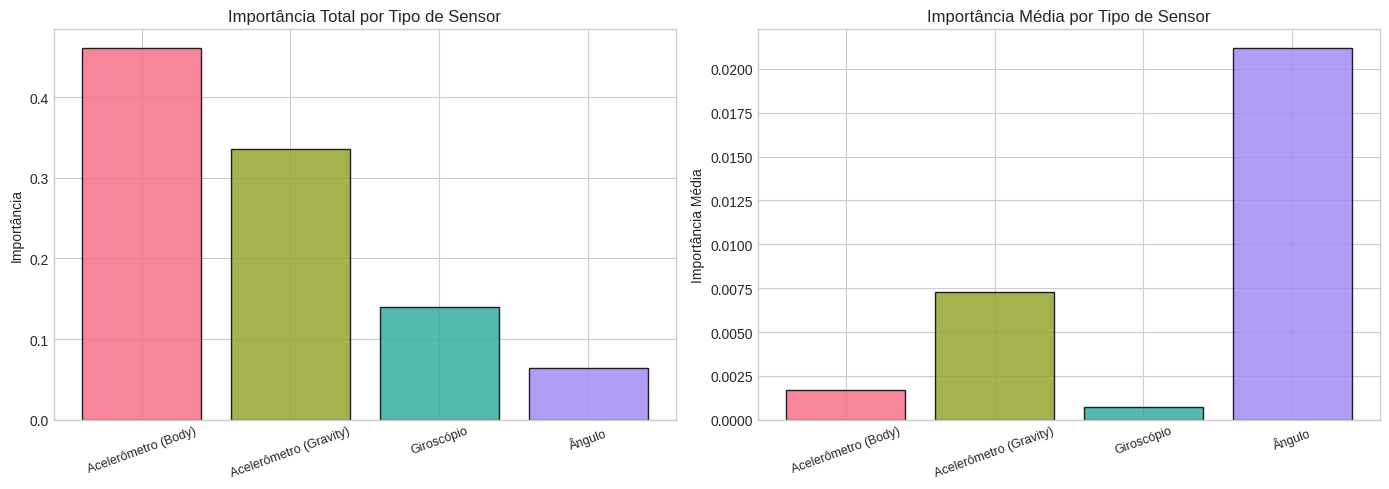

In [36]:
# Classificar features por tipo de sensor
sensor_importance = {}
for feat, imp in zip(kept_features, importances):
    if 'Acc' in feat and 'Gravity' not in feat:
        sensor = 'Acelerômetro (Body)'
    elif 'Gravity' in feat:
        sensor = 'Acelerômetro (Gravity)'
    elif 'Gyro' in feat:
        sensor = 'Giroscópio'
    elif 'angle' in feat.lower():
        sensor = 'Ângulo'
    else:
        sensor = 'Outro'
    sensor_importance.setdefault(sensor, []).append(imp)

# Soma da importância por tipo de sensor
sensor_summary = {k: (sum(v), len(v), np.mean(v)) for k, v in sensor_importance.items()}
sensor_df = pd.DataFrame(sensor_summary, index=['Importância Total', 'Qtd Features', 'Importância Média']).T
sensor_df = sensor_df.sort_values('Importância Total', ascending=False)

print('Importância por tipo de sensor:')
print(sensor_df.round(4))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('husl', n_colors=len(sensor_df))
axes[0].bar(sensor_df.index, sensor_df['Importância Total'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Importância Total por Tipo de Sensor', fontsize=12)
axes[0].set_ylabel('Importância')
axes[0].tick_params(axis='x', rotation=20, labelsize=9)

axes[1].bar(sensor_df.index, sensor_df['Importância Média'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Importância Média por Tipo de Sensor', fontsize=12)
axes[1].set_ylabel('Importância Média')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.show()

### 4.6 Trade-off: Acurácia vs. Tempo de Inferência

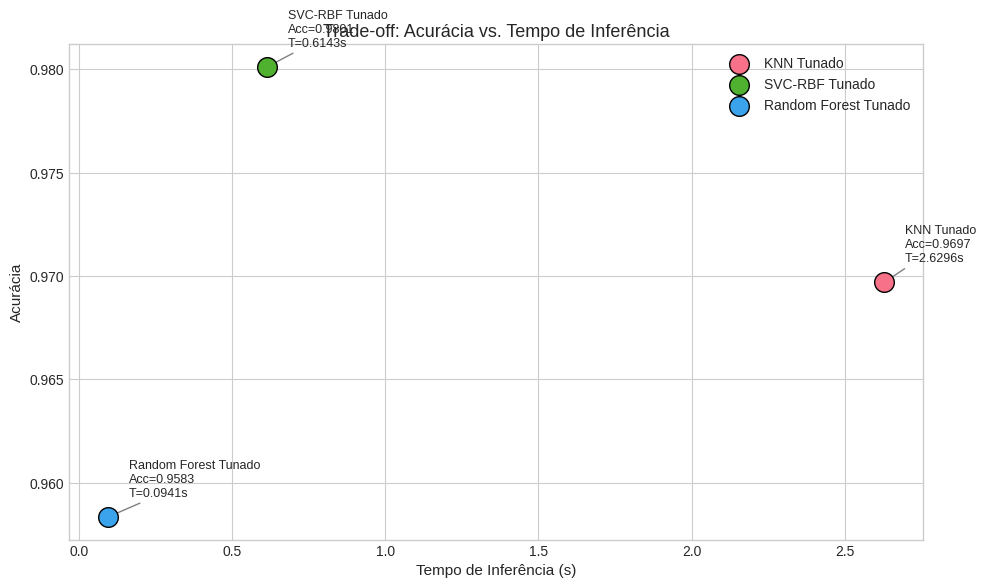

Trade-off:
  KNN Tunado       Acc: 0.9697  |  Inferência: 2.6296s
  SVC-RBF Tunado   Acc: 0.9801  |  Inferência: 0.6143s
  Random Forest Tunado Acc: 0.9583  |  Inferência: 0.0941s


In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('husl', n_colors=3)
for i, (name, res) in enumerate(test_results.items()):
    ax.scatter(res['inference_time'], res['accuracy'],
               s=200, color=colors[i], edgecolors='black',
               zorder=5, label=name)
    ax.annotate(f'{name}\nAcc={res["accuracy"]:.4f}\nT={res["inference_time"]:.4f}s',
                xy=(res['inference_time'], res['accuracy']),
                xytext=(15, 15), textcoords='offset points',
                fontsize=9, ha='left',
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Tempo de Inferência (s)', fontsize=11)
ax.set_ylabel('Acurácia', fontsize=11)
ax.set_title('Trade-off: Acurácia vs. Tempo de Inferência', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Trade-off:')
for name, res in test_results.items():
    print(f'  {name:<16} Acc: {res["accuracy"]:.4f}  |  Inferência: {res["inference_time"]:.4f}s')

### 4.7 Comparação de F1-Score por Classe

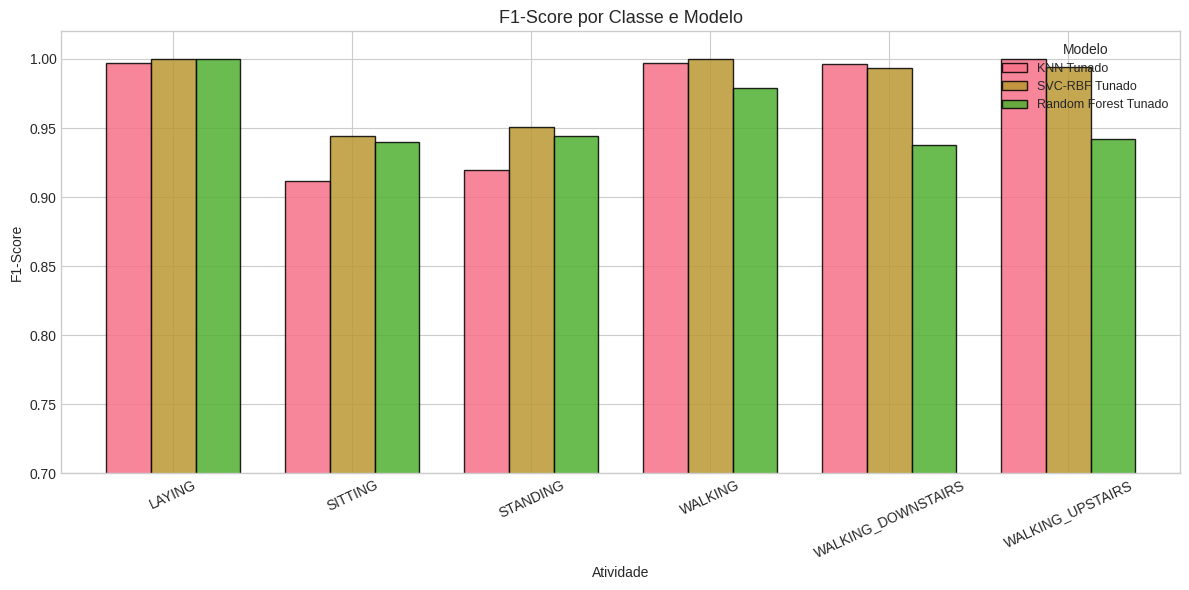

F1-Score por classe:
                    KNN Tunado  SVC-RBF Tunado  Random Forest Tunado
LAYING                  0.9973          1.0000                1.0000
SITTING                 0.9118          0.9440                0.9398
STANDING                0.9195          0.9506                0.9440
WALKING                 0.9974          1.0000                0.9789
WALKING_DOWNSTAIRS      0.9967          0.9933                0.9377
WALKING_UPSTAIRS        1.0000          0.9939                0.9419


In [38]:
# F1 por classe para cada modelo
f1_per_class = {}
for name, res in test_results.items():
    f1_per_class[name] = f1_score(y_test, res['y_pred'], average=None)

df_f1 = pd.DataFrame(f1_per_class, index=le.classes_)

fig, ax = plt.subplots(figsize=(12, 6))
df_f1.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.85, width=0.75)
ax.set_title('F1-Score por Classe e Modelo', fontsize=13)
ax.set_ylabel('F1-Score')
ax.set_xlabel('Atividade')
ax.set_ylim(0.7, 1.02)
ax.legend(title='Modelo', fontsize=9)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

print('F1-Score por classe:')
print(df_f1.round(4))

---
## Conclusão

### Resultados
- Os três modelos avaliados (KNN Tunado, SVC-RBF Tunado, Random Forest Tunado) obtiveram desempenho elevado na classificação de atividades humanas.
- O **SVC (RBF) Tunado** tende a ser o melhor modelo neste dataset, confirmando a expectativa para dados com muitas features e separação não-linear entre classes.

### Padrões de Confusão
- As atividades **Walking, Walking_Upstairs e Walking_Downstairs** são as mais confundidas entre si, devido à similaridade nos padrões de aceleração.
- **Sitting e Standing** apresentam confusão mútua por serem atividades estáticas com perfis sensoriais próximos.
- **Laying** é a atividade mais fácil de classificar, com padrões muito distintos.

### Features Informativas
- Sinais do acelerômetro (gravidade e corpo) concentram a maior parte da importância.
- Features de ângulo e domínio de frequência também contribuem significativamente.
- As 561 features já pré-extraídas pelo pipeline de signal processing facilitam a classificação.

### Trade-off
- **SVC-RBF Tunado**: melhor acurácia, porém tempo de inferência potencialmente maior para datasets grandes.
- **Random Forest Tunado**: boa acurácia com inferência rápida e interpretável (feature importance).
- **KNN Tunado**: competitivo, mas mais sensível à escala e dimensionalidade.